In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [164]:
# 1. Load Dataset
df = sns.load_dataset("titanic")

In [176]:
# 2. First 5 Rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,True


In [177]:
# 3. Shape
print("Rows and Columns :", df.shape)

Rows and Columns : (891, 13)


In [178]:
# 4. Column Names
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone'],
      dtype='str')

In [179]:
# 5. Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    str     
 12  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 89.9 KB


In [180]:
# 6. Statistical Summary
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [181]:
# 7. Missing Values
df.isnull().sum()
# Missing Values Percentage
missing_percent = (df.isnull().sum()/len(df))*100
print("\nMissing Percentage")
print(missing_percent)


Missing Percentage
survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alone          0.0
dtype: float64


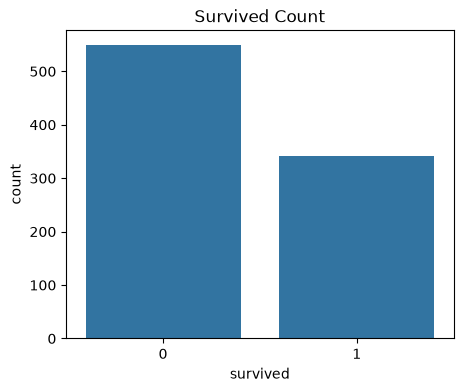

In [172]:
# 8. Target Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="survived", data=df)
plt.title("Survived Count")
plt.show()


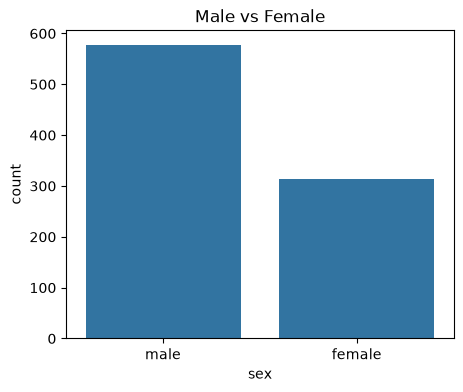

In [173]:
# 9. Passenger Gender
# ==========================
plt.figure(figsize=(5,4))
sns.countplot(x="sex", data=df)
plt.title("Male vs Female")
plt.show()

# Data Preprocessing

In [182]:
import pandas as pd
import seaborn as sns

In [183]:
# 1. Load Dataset
df = sns.load_dataset("titanic")

In [184]:
# 2. Check Missing Values

print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [185]:
# 3. Drop Unnecessary Column
# deck has more than 77% missing values
df.drop("deck", axis=1, inplace=True)

In [186]:
# alive is the same information as survived
df.drop("alive", axis=1, inplace=True)

In [188]:
# 4. Fill Missing Values
# Numerical Column
df["age"] = df["age"].fillna(df["age"].mean())

# Categorical Columns
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [189]:
# Sex
df["sex"] = df["sex"].map({
    "male": 1,
    "female": 0
})

In [190]:
# Embarked
df["embarked"] = df["embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [191]:
# Passenger Class
df["class"] = df["class"].map({
    "First": 1,
    "Second": 2,
    "Third": 3
})

In [192]:
# Who
df["who"] = df["who"].map({
    "man": 0,
    "woman": 1,
    "child": 2
})

In [193]:
# Embark Town
df["embark_town"] = df["embark_town"].map({
    "Southampton": 0,
    "Cherbourg": 1,
    "Queenstown": 2
})

In [195]:
print("\nFirst 5 Rows")
df.head()


First 5 Rows


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,0,3,0,True,0,False
1,1,1,0,38.0,1,0,71.2833,1,1,1,False,1,False
2,1,3,0,26.0,0,0,7.9250,0,3,1,False,0,True
3,1,1,0,35.0,1,0,53.1000,0,1,1,False,0,False
4,0,3,1,35.0,0,0,8.0500,0,3,0,True,0,True


In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    int64   
 8   class        891 non-null    category
 9   who          891 non-null    int64   
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    int64   
 12  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(8)
memory usage: 72.4 KB


# Decision Tree Classification

In [197]:
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [198]:
# 1. Features and Target

X = df.drop("survived", axis=1)
y = df["survived"]

In [199]:
# 2. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [200]:
# 3. Unpruned Model
unpruned_model = DecisionTreeClassifier(random_state=42)

unpruned_model.fit(X_train, y_train)

print("========== Unpruned Model ==========")

print("Training Accuracy :",
      accuracy_score(y_train, unpruned_model.predict(X_train)))

print("Testing Accuracy  :",
      accuracy_score(y_test, unpruned_model.predict(X_test)))

========== Unpruned Model ==========
Training Accuracy : 0.9807383627608347
Testing Accuracy  : 0.7910447761194029


In [201]:
# 4. Pruned Models

for depth in [2,3,4]:

    print(f"\n========== max_depth = {depth} ==========")

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)


========== max_depth = 2 ==========
Training Accuracy : 0.797752808988764
Testing Accuracy  : 0.7686567164179104

========== max_depth = 3 ==========
Training Accuracy : 0.8362760834670947
Testing Accuracy  : 0.8208955223880597

========== max_depth = 4 ==========
Training Accuracy : 0.841091492776886
Testing Accuracy  : 0.8022388059701493


In [202]:
# 5. Best Model

best_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

best_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

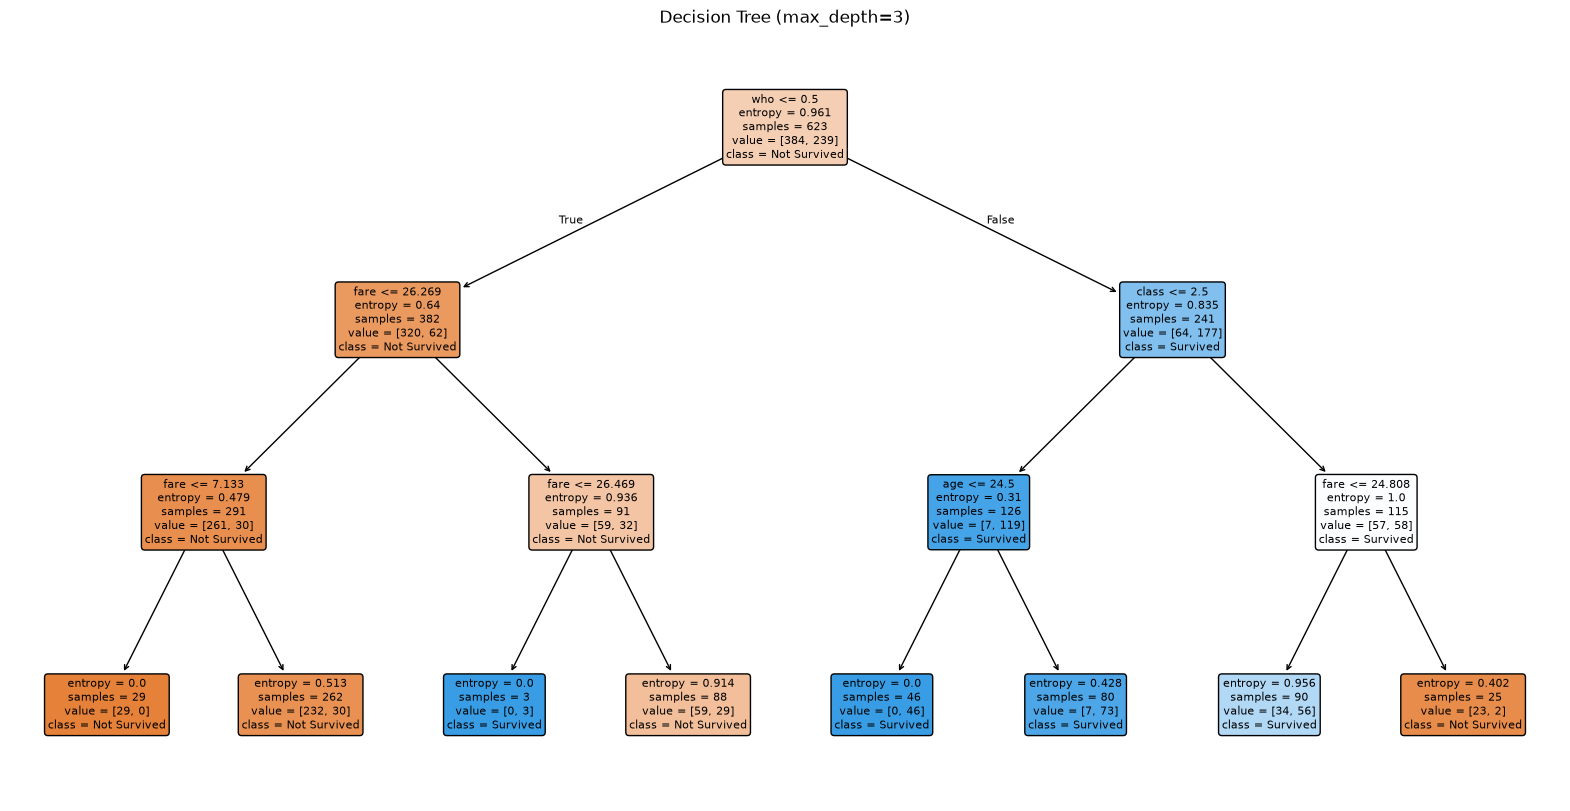

In [203]:
# 6. Decision Tree Visualization

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Not Survived","Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree (max_depth=3)")

plt.show()